In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/19
    print("準備完了！このまま下のセルを実行できます。")

# 第19章 自己符号化器 (Autoencoders)
## 19.2 変分自己符号化器 (Variational Autoencoders; VAE)

本ノートブックは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第19章「自己符号化器」第2節「変分自己符号化器 (Variational Autoencoders)」の理論的背景、数式厳密導出、および完全なPython実装を提供します。

---

### 概要とモチベーション：決定論的AEから確率的深層生成モデルへ

前節 **19.1 決定論的自己符号化器** では、ボトルネックや正則化を通じて有用な内部表現を獲得しました。しかし、潜在空間 $\mathbf{z}$ に確率分布が定義されていないため、潜在空間から新規データをサンプリングして生成することが困難でした。

本節で扱う**変分自己符号化器 (Variational Autoencoder; VAE)**（Kingma & Welling, 2013; Rezende et al., 2014）は、第16章の線形潜在変数モデル（確率的PCA）を深層ニューラルネットワークへと拡張する、非線形潜在変数モデルの第3のアプローチです：

1. **周辺尤度の難解性 (Intractability)**:
   深層生成モデル $p(\mathbf{x}|\mathbf{w}) = \int p(\mathbf{x}|\mathbf{z}, \mathbf{w}) p(\mathbf{z}) d\mathbf{z}$（式 19.4）は積分が解析的に評価不可能。
2. **変分下界 (ELBO)**:
   真の対数尤度の代わりに証拠下界（Evidence Lower Bound; ELBO）$\mathcal{L}(\mathbf{w}, \boldsymbol{\phi})$ を導出し、最大化する。
3. **償却推論 (Amortized Inference, §19.2.1)**:
   データ点ごとに個別の変分事後分布を最適化する（計算コスト大）代わりに、単一のエンコーダネットワーク $q(\mathbf{z}|\mathbf{x}, \boldsymbol{\phi})$ を用いて一括で事後分布パラメータを推論する。
4. **再パラメータ化トリック (The Reparameterization Trick, §19.2.2)**:
   確率的サンプリングを $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$ と決定論的変換＋独立ノイズに分解することで、誤差逆伝播を可能にし、勾配の分散を大幅に削減する。


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートのパス解決
sys.path.append(os.path.abspath(".."))

from common.plot_utils import setup_style
from common.variational_autoencoders import (
    GaussianEncoder,
    GaussianDecoder,
    VariationalAutoencoder,
    generate_figure_19_7,
    generate_figure_19_8,
    generate_figure_19_9,
    generate_figure_19_10,
    generate_figure_19_11,
)

setup_style()
print("モジュールと可視化スタイルのロードが完了しました。")


モジュールと可視化スタイルのロードが完了しました。


---
## 変分下界 (ELBO) の厳密な数学的導出

潜在変数モデルにおいて、潜在変数 $\mathbf{z}$ 上の事前分布を標準ガウス分布とします：

$$p(\mathbf{z}) = \mathcal{N}(\mathbf{z} \mid \mathbf{0}, \mathbf{I}) \quad (19.5)$$

生成モデル（デコーダー）の条件付き分布 $p(\mathbf{x}|\mathbf{z}, \mathbf{w})$ は深層ニューラルネットワーク $\mathbf{g}(\mathbf{z}, \mathbf{w})$ によって制御されます。
任意の変分確率分布 $q(\mathbf{z})$ に対して、真の対数尤度は次のように厳密に分解されます：

$$\ln p(\mathbf{x} \mid \mathbf{w}) = \mathcal{L}(\mathbf{w}, q) + \mathrm{KL}(q(\mathbf{z}) \parallel p(\mathbf{z} \mid \mathbf{x}, \mathbf{w})) \quad (19.6)$$

ここで、$\mathcal{L}(\mathbf{w}, q)$ は**変分下界 (ELBO; Evidence Lower Bound)**：

$$\mathcal{L}(\mathbf{w}, q) = \int q(\mathbf{z}) \ln \left\{ \frac{p(\mathbf{x} \mid \mathbf{z}, \mathbf{w}) p(\mathbf{z})}{q(\mathbf{z})} \right\} d\mathbf{z} \quad (19.7)$$

Kullback–Leibler (KL) ダイバージェンスは非負 ($\mathrm{KL} \ge 0$) であるため：

$$\ln p(\mathbf{x} \mid \mathbf{w}) \ge \mathcal{L}(\mathbf{w}, q) \quad (19.9)$$

独立同分布 (i.i.d.) なデータセット $\mathcal{D} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ に対する対数尤度は：

$$\ln p(\mathcal{D} \mid \mathbf{w}) = \sum_{n=1}^N \mathcal{L}_n + \sum_{n=1}^N \mathrm{KL}(q_n(\mathbf{z}_n) \parallel p(\mathbf{z}_n \mid \mathbf{x}_n, \mathbf{w})) \quad (19.10)$$

ここで各データ点 $\mathbf{x}_n$ ごとに独立な潜在変数 $\mathbf{z}_n$ と変分事後分布 $q_n(\mathbf{z}_n)$ が導入されます。
真の事後分布はベイズの定理より：

$$p(\mathbf{z}_n \mid \mathbf{x}_n, \mathbf{w}) = \frac{p(\mathbf{x}_n \mid \mathbf{z}_n, \mathbf{w}) p(\mathbf{z}_n)}{p(\mathbf{x}_n \mid \mathbf{w})} \quad (19.12)$$

分母の $p(\mathbf{x}_n \mid \mathbf{w})$ が計算困難であるため、厳密な事後分布を求めることはできません。


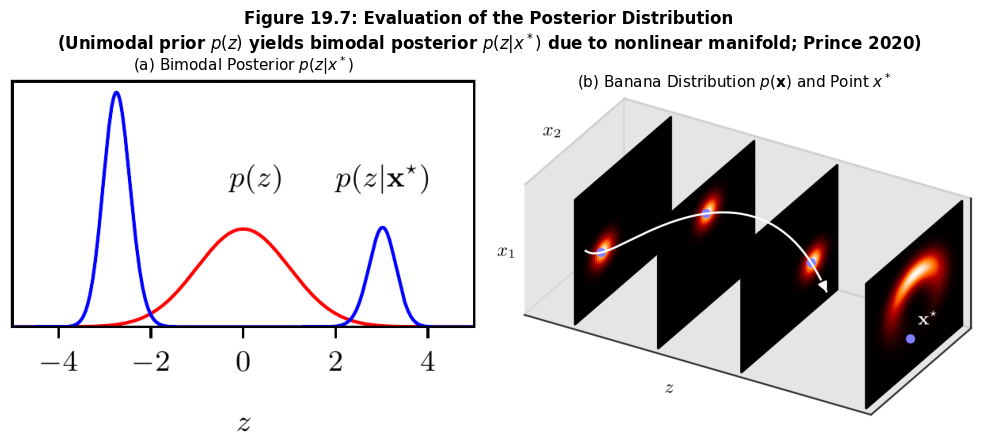

In [3]:
# Figure 19.7 の表示 (非線形モデルにおける事後分布の多峰性)
fig19_7 = generate_figure_19_7()
plt.show()


---
## 19.2.1 償却推論 (Amortized Inference)

データ点 $\mathbf{x}_n$ ごとに別々の事後分布 $q_n(\mathbf{z}_n)$ を個別に最適化する（変分EMアルゴリズムのEステップ）代わりに、VAEでは**単一のニューラルネットワーク（エンコーダ）$q(\mathbf{z} \mid \mathbf{x}, \boldsymbol{\phi})$** を訓練してすべての事後分布を一括で近似します。これを**償却推論 (Amortized Inference)** と呼びます。

エンコーダは対角共分散行列を持つガウス分布を出力します：

$$q(\mathbf{z} \mid \mathbf{x}, \boldsymbol{\phi}) = \prod_{j=1}^M \mathcal{N}\left(z_j \mid \mu_j(\mathbf{x}, \boldsymbol{\phi}), \sigma_j^2(\mathbf{x}, \boldsymbol{\phi})\right) \quad (19.13)$$

### ELBO 最適化と EM アルゴリズムの比較 (Figures 19.8, 19.9)
- **EM アルゴリズム (Figure 19.9 a)**: Eステップで厳密な事後分布 $p(\mathbf{z}|\mathbf{x})$ を求めるため、KLギャップはゼロになり、ELBOが真の対数尤度に一致します。
- **VAE の償却推論 (Figure 19.8, Figure 19.9 b)**:
  1. エンコーダの柔軟性が有限であること
  2. 真の事後分布が非対角・非ガウス多峰性であること（Figure 19.7 参照）
  3. 最適化が局所解にとどまること
  のため、$\boldsymbol{\phi}$ を最適化しても**残余 KL ギャップ (Amortization gap)** が残り、ELBO は真の対数尤度の厳密な下界にとどまります。


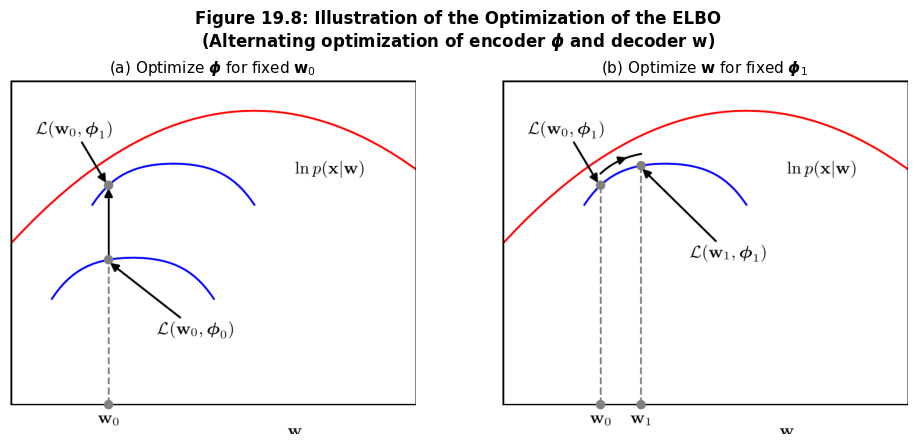

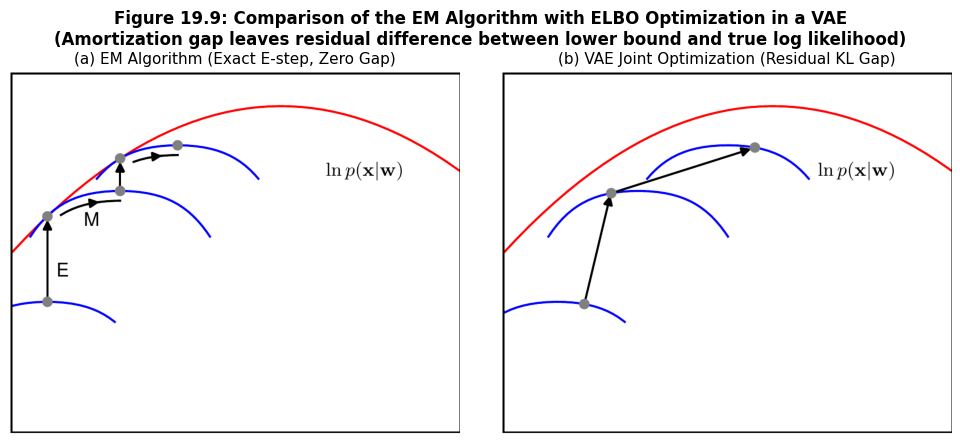

In [4]:
# Figure 19.8 および Figure 19.9 の表示
fig19_8 = generate_figure_19_8()
plt.show()

fig19_9 = generate_figure_19_9()
plt.show()


---
## 19.2.2 再パラメータ化トリック (The Reparameterization Trick)

データ点 $\mathbf{x}_n$ に対する ELBO の寄与は、2つの項に明確に分離できます：

$$\mathcal{L}_n(\mathbf{w}, \boldsymbol{\phi}) = \mathbb{E}_{q(\mathbf{z}_n \mid \mathbf{x}_n, \boldsymbol{\phi})} [\ln p(\mathbf{x}_n \mid \mathbf{z}_n, \mathbf{w})] - \mathrm{KL}(q(\mathbf{z}_n \mid \mathbf{x}_n, \boldsymbol{\phi}) \parallel p(\mathbf{z}_n)) \quad (19.14)$$

### 1. 解析的 ガウス KL ダイバージェンス (Eq. 19.15)
第2項の KL ダイバージェンスは、2つの多変量ガウス分布間の積分として**解析的**に求まります：

$$\mathrm{KL}\left(q(\mathbf{z}_n \mid \mathbf{x}_n, \boldsymbol{\phi}) \parallel p(\mathbf{z}_n)\right) = -\frac{1}{2} \sum_{j=1}^M \left( 1 + \ln \sigma_{nj}^2 - \mu_{nj}^2 - \sigma_{nj}^2 \right) \quad (19.15)$$

### 2. 再パラメータ化トリックによる逆伝播の実現 (Figures 19.10, 19.11)
第1項の期待値 $\mathbb{E}_q [\ln p(\mathbf{x}|\mathbf{z})]$ について、直接 $\mathbf{z} \sim q(\mathbf{z}|\mathbf{x}, \boldsymbol{\phi})$ をサンプリングすると、サンプリングノードで誤差逆伝播の信号が遮断されてしまいます（**Figure 19.10**）。

そこで、標準正規分布からの独立ノイズ $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ を抽出し、決定論的なアフィン変換によって潜在変数 $\mathbf{z}$ を構成します（**式 19.17 - 19.18**）：

$$z_{nj} = \mu_j(\mathbf{x}_n, \boldsymbol{\phi}) + \sigma_j(\mathbf{x}_n, \boldsymbol{\phi}) \odot \epsilon_{nj}, \quad \epsilon_{nj} \sim \mathcal{N}(0, 1) \quad (19.18)$$

これにより、$\boldsymbol{\phi}$ に対する依存関係が明示的になり、デコーダからの誤差信号が $\mathbf{z}$ を通じて $\boldsymbol{\mu}$ および $\boldsymbol{\sigma}$、そしてエンコーダのパラメータ $\boldsymbol{\phi}$ へと滞りなく逆伝播します（**Figure 19.11**）。


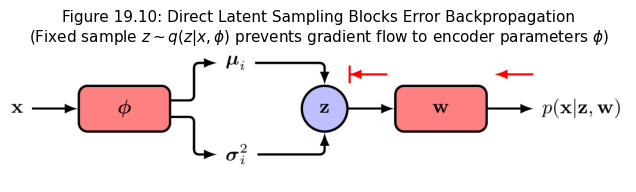

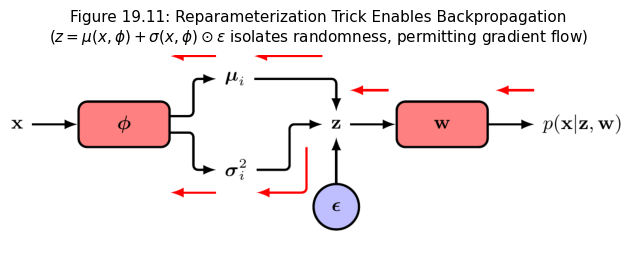

In [5]:
# Figure 19.10 および Figure 19.11 の表示
fig19_10 = generate_figure_19_10()
plt.show()

fig19_11 = generate_figure_19_11()
plt.show()


---
## VAE 全体誤差関数 (式 19.19) と 学習アルゴリズム (Algorithm 19.1)

モンテカルロサンプル数を $L=1$ と置いたミニバッチ全体の最大化目的関数（負の損失関数）は式 (19.19) となります：

$$\mathcal{L} = \sum_{n} \left\{ \frac{1}{2} \sum_{j=1}^M \left( 1 + \ln \sigma_{nj}^2 - \mu_{nj}^2 - \sigma_{nj}^2 \right) + \ln p(\mathbf{x}_n \mid \mathbf{z}_n, \mathbf{w}) \right\} \quad (19.19)$$

### Algorithm 19.1: Variational autoencoder training
```
Input: Training data set D = {x_1, ..., x_N}
       Encoder network {mu_j(x, \phi), \sigma_j^2(x, \phi)}
       Decoder network g(z, w)
       Learning rate \eta
Repeat:
    1. Sample noise: \epsilon_n ~ N(0, I)
    2. Reparameterize: z_n = \mu(x_n, \phi) + \sigma(x_n, \phi) \odot \epsilon_n
    3. Evaluate ELBO: L = -KL + \ln p(x_n | z_n, w)
    4. Gradient update: w <- w + \eta \nabla_w L
                        \phi <- \phi + \eta \nabla_\phi L
Until converged
```


[学習前] ELBO: -34.7505 (Recon: -34.5648, KL: 0.1858)


[学習後] ELBO: -2.3909 (Recon: 0.5302, KL: 2.9210)
==> ELBO 改善度: +32.3597


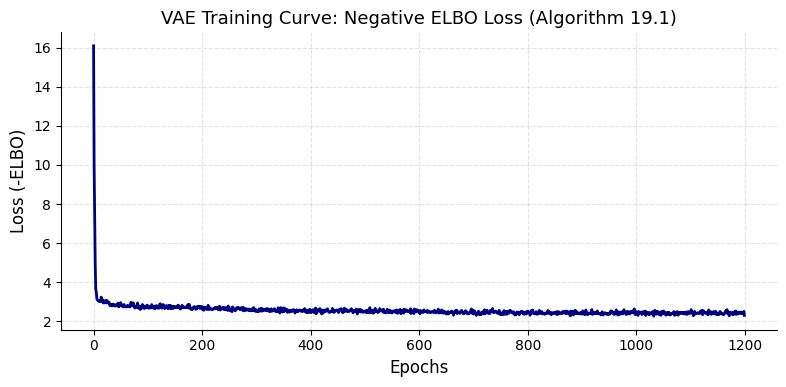

In [6]:
# === 19.2.1 実験: VAE の学習と ELBO の収束 ===
np.random.seed(42)
N = 600

# 2次元空間内の非線形な8の字 (Lemniscate) 多様体データを生成
t = np.random.uniform(0, 2 * np.pi, N)
scale = 2.5
x1_true = scale * np.cos(t) / (1 + np.sin(t)**2)
x2_true = scale * np.sin(t) * np.cos(t) / (1 + np.sin(t)**2)
x_data = np.column_stack([x1_true, x2_true]) + np.random.randn(N, 2) * 0.08

# VAE モデルの構築 (入力 2D, 隠れ層 32D, 潜在空間 2D)
vae = VariationalAutoencoder(
    input_dim=2,
    hidden_dim=32,
    latent_dim=2,
    obs_noise_std=0.2,
    beta=1.0,
    activation='tanh',
    seed=42,
)

init_elbo, init_recon, init_kl = vae.compute_elbo(x_data)
print(f"[学習前] ELBO: {init_elbo:.4f} (Recon: {init_recon:.4f}, KL: {init_kl:.4f})")

# 学習の実行 (Algorithm 19.1)
loss_history = vae.fit(x_data, n_epochs=1200, lr=0.008, batch_size=64)

final_elbo, final_recon, final_kl = vae.compute_elbo(x_data)
print(f"[学習後] ELBO: {final_elbo:.4f} (Recon: {final_recon:.4f}, KL: {final_kl:.4f})")
print(f"==> ELBO 改善度: {final_elbo - init_elbo:+.4f}")

# 学習曲線 (負の ELBO = 損失) の可視化
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='navy', lw=2)
ax.set_title("VAE Training Curve: Negative ELBO Loss (Algorithm 19.1)")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss (-ELBO)")
plt.tight_layout()
plt.show()


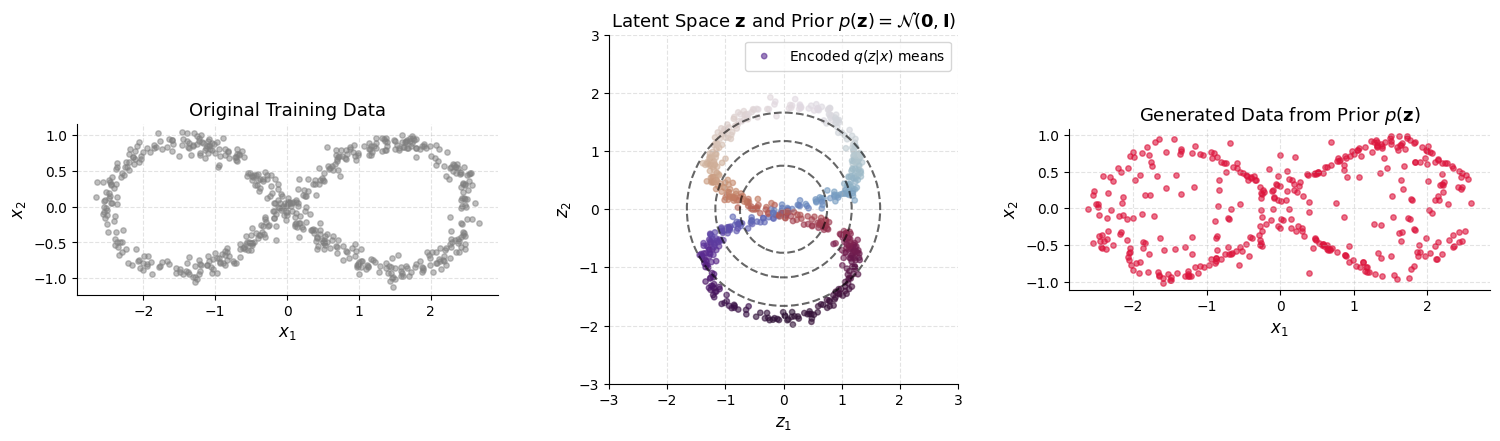

In [7]:
# === 19.2.2 実験: 潜在空間の分布と新規データサンプリング ===
# 1. 訓練データを潜在空間へエンコードして可視化
mu_z, logvar_z = vae.encode(x_data)

# 2. 事前分布 p(z) ~ N(0, I) からの新規サンプル生成
n_gen = 400
x_generated = vae.sample_prior(n_samples=n_gen)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) 元のデータセット
axes[0].scatter(x_data[:, 0], x_data[:, 1], c='gray', alpha=0.5, s=15)
axes[0].set_title("Original Training Data")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")
axes[0].set_aspect('equal')

# (b) 潜在空間 z のエンコード分布 q(z|x) と事前分布 N(0, I)
axes[1].scatter(mu_z[:, 0], mu_z[:, 1], c=t, cmap='twilight', alpha=0.6, s=15, label="Encoded $q(z|x)$ means")
# 事前分布の等高線
grid_z = np.linspace(-3, 3, 50)
gz1, gz2 = np.meshgrid(grid_z, grid_z)
prior_contour = np.exp(-0.5 * (gz1**2 + gz2**2)) / (2 * np.pi)
axes[1].contour(gz1, gz2, prior_contour, levels=4, colors='black', linestyles='--', alpha=0.6)
axes[1].set_title(r"Latent Space $\mathbf{z}$ and Prior $p(\mathbf{z})=\mathcal{N}(\mathbf{0}, \mathbf{I})$")
axes[1].set_xlabel("$z_1$"); axes[1].set_ylabel("$z_2$")
axes[1].set_aspect('equal')
axes[1].legend(loc='upper right')

# (c) 事前分布サンプリングによる新規生成データ
axes[2].scatter(x_generated[:, 0], x_generated[:, 1], c='crimson', alpha=0.6, s=15)
axes[2].set_title("Generated Data from Prior $p(\mathbf{z})$")
axes[2].set_xlabel("$x_1$"); axes[2].set_ylabel("$x_2$")
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()


beta = 0.05 | Recon Log-lik:     1.28 | KL:  5.938 | ELBO:     0.98


beta = 0.50 | Recon Log-lik:     0.85 | KL:  3.466 | ELBO:    -0.88


beta = 1.00 | Recon Log-lik:     0.46 | KL:  2.906 | ELBO:    -2.44


beta = 4.00 | Recon Log-lik:    -1.98 | KL:  1.829 | ELBO:    -9.30


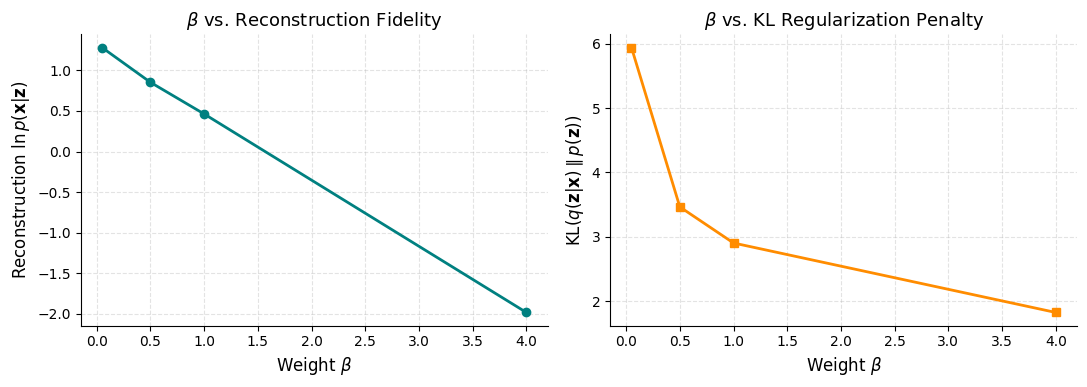

In [8]:
# === 19.2.3 実験: beta-VAE と事後崩壊 (Posterior Collapse) の解析 ===
# beta の値を変化させて KL項と復元項のトレードオフを検証
betas = [0.05, 0.5, 1.0, 4.0]
results = []

for b in betas:
    model_b = VariationalAutoencoder(
        input_dim=2, hidden_dim=32, latent_dim=2, obs_noise_std=0.2, beta=b, seed=42
    )
    model_b.fit(x_data, n_epochs=800, lr=0.008, batch_size=64)
    elbo_b, recon_b, kl_b = model_b.compute_elbo(x_data, beta=b)
    results.append((b, elbo_b, recon_b, kl_b))
    print(f"beta = {b:4.2f} | Recon Log-lik: {recon_b:8.2f} | KL: {kl_b:6.3f} | ELBO: {elbo_b:8.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
b_vals = [r[0] for r in results]
recons = [r[2] for r in results]
kls = [r[3] for r in results]

ax1.plot(b_vals, recons, marker='o', color='teal', lw=2)
ax1.set_xlabel(r"Weight $\beta$")
ax1.set_ylabel(r"Reconstruction $\ln p(\mathbf{x}|\mathbf{z})$")
ax1.set_title(r"$\beta$ vs. Reconstruction Fidelity")

ax2.plot(b_vals, kls, marker='s', color='darkorange', lw=2)
ax2.set_xlabel(r"Weight $\beta$")
ax2.set_ylabel(r"$\mathrm{KL}(q(\mathbf{z}|\mathbf{x}) \parallel p(\mathbf{z}))$")
ax2.set_title(r"$\beta$ vs. KL Regularization Penalty")
plt.tight_layout()
plt.show()


---
## 第19章 全体のまとめと結論

本章では、深層学習における内部表現学習の中核技術である自己符号化器（Autoencoders）を体系的に学習しました：

1. **決定論的自己符号化器 (§19.1)**:
   - **線形自己符号化器**: 線形 PCA と数学的に等価であり、非線形隠れ層を用いても主成分部分空間に収束する（Bourlard & Kamp, 1988）。
   - **深層自己符号化器**: 複数の非線形層を積み重ねることで非線形 PCA を実現し、曲がった多様体 $\mathcal{S}$ を捉える（Figure 19.3）。
   - **正則化**: スパース自己符号化器（$L_1$ 活性化正則化）やノイズ除去自己符号化器（スコアマッチングとの等価性、Figure 19.4）。
   - **マスク自己符号化器 (MAE)**: 高比率パッチマスキング（80%）と非対称 ViT により、画像表現学習において驚異的な性能を達成（Figures 19.5, 19.6）。

2. **変分自己符号化器 (§19.2)**:
   - **確率的潜在変数モデル**: 潜在空間に連続的な事前分布 $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ を導入し、深層生成モデルを実現。
   - **変分下界 (ELBO)**: 難解な周辺対数尤度を近似する下界を導出（式 19.14）。
   - **償却推論**: 単一のエンコーダ $q(\mathbf{z}|\mathbf{x}, \boldsymbol{\phi})$ により、全データの変分事後分布を一括推論（EM アルゴリズムとの対比、Figures 19.8, 19.9）。
   - **再パラメータ化トリック**: 確率的ノイズを分離し、エンドツーエンドの勾配計算と低分散な最適化を実現（Figures 19.10, 19.11）。
   - **事後崩壊と $\beta$-VAE**: 復元項と正則化項のバランスを制御し、高品質な生成と表現の解きほぐしを両立。

---

### 次のステップ: 第19章 演習問題 (Exercises 19.1 〜 19.6)
次節では、第19章の全6問の演習問題（理論証明、スコア関数導出、変分下界の評価など）に取り組みます。
